# **📚 Book Recommendation System: Collaborative Filtering and Matrix Factorization**

## **I. Introduction**

### **i. Context**

With more than **3.5 billion people using the internet worldwide**, online retail has become a major component of modern commerce, and global **e-commerce sales continue to grow steadily each year**. As online marketplaces expand, helping users efficiently discover relevant products has become increasingly important. One key solution is the implementation of **recommendation systems**, which personalize product suggestions based on user behavior and preferences.

In the context of online bookstores, a **book recommendation system** suggests books that are likely to match a reader’s interests by analyzing patterns such as previous purchases, ratings, or interactions. These systems help users navigate large catalogs of titles and discover books that align with their preferences.

Many major e-commerce platforms—including Amazon, Barnes & Noble, Flipkart, and Goodreads—rely heavily on recommendation systems to enhance the shopping experience. By providing personalized suggestions, these systems **reduce search time, improve user satisfaction, and increase purchase likelihood**. Effective recommendations not only help customers make better purchasing decisions but also contribute to **higher engagement and increased overall sales for online retailers**.

### **ii. Objective**

With more than **3.5 billion people using the internet worldwide**, online retail has become a major component of modern commerce, and global **e-commerce sales continue to grow steadily each year**. As online marketplaces expand, helping users efficiently discover relevant products has become increasingly important. One key solution is the implementation of **recommendation systems**, which personalize product suggestions based on user behavior and preferences.

In the context of online bookstores, a **book recommendation system** suggests books that are likely to match a reader’s interests by analyzing patterns such as previous purchases, ratings, or interactions. These systems help users navigate large catalogs of titles and discover books that align with their preferences.

Many major e-commerce platforms—including Amazon, Barnes & Noble, Flipkart, and Goodreads—rely heavily on recommendation systems to enhance the shopping experience. By providing personalized suggestions, these systems **reduce search time, improve user satisfaction, and increase purchase likelihood**. Effective recommendations not only help customers make better purchasing decisions but also contribute to **higher engagement and increased overall sales for online retailers**.

### **iii. Dataset**

The **ratings** dataset contains information about user interactions with books and includes the following attributes:

- **User-ID**: Unique identifier assigned to each user  
- **ISBN**: International Standard Book Number used to uniquely identify each book  
- **Book-Rating**: Rating given by the user for a book, measured on a scale from **0 to 10**

In addition, the **books** dataset provides descriptive information about each book and includes the following attributes:

- **ISBN**: International Standard Book Number identifying the book  
- **Book-Title**: Title of the book  
- **Book-Author**: Name of the author  
- **Year-of-Publication**: Year the book was published  
- **Publisher**: Name of the publishing company  
- **Image-URL-S**: Link to a small-sized image of the book cover (Amazon)  
- **Image-URL-M**: Link to a medium-sized image of the book cover (Amazon)  
- **Image-URL-L**: Link to a large-sized image of the book cover (Amazon)  

Sometimes, the installation of the surprise library, which is used to build recommendation systems, faces issues in Jupyter. To avoid any issues, it is advised to use **Google Colab** for this project.

Let's start by mounting the Google drive on Colab.

In [ ]:
# Mount your drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Installing surprise library
!pip install surprise

In [ ]:
# Basic python libraries
import numpy as np
import pandas as pd

# Python libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD
from collections import defaultdict

# For implementing cross validation
from surprise.model_selection import KFold

import warnings
warnings.filterwarnings('ignore')

### **iv. Library**

In [1]:
# I. ----- Introduction -----
# This chapter does not have 

# II. ----- Dataset -----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# III. ----- Models -----
from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.model_selection import GridSearchCV
from surprise.model_selection import train_test_split
from surprise.prediction_algorithms.knns import KNNBasic
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
import numpy as np
from surprise.prediction_algorithms.matrix_factorization import SVD

## **II. Data Pipeline**

### **i. Data Overview**

In [2]:
book = pd.read_csv("Books.csv")
rating = pd.read_csv("Ratings.csv")
user = pd.read_csv("Users.csv")

/opt/anaconda3/envs/surprise/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3308: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [3]:
rating.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [4]:
book.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


**Merge datasets**

In [5]:
df = pd.merge(rating, book.drop_duplicates(['ISBN']), on="ISBN", how="left")
df.drop(['Image-URL-S','Image-URL-M','Image-URL-L'], axis =1, inplace = True)
df.rename(columns = {'User-ID':'user_id', 'ISBN':'book_id', "Book-Rating":"rating"}, inplace = True)
df.head()

,user_id,book_id,rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1149780 entries, 0 to 1149779
Data columns (total 7 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   user_id              1149780 non-null  int64 
 1   book_id              1149780 non-null  object
 2   rating               1149780 non-null  int64 
 3   Book-Title           1031136 non-null  object
 4   Book-Author          1031135 non-null  object
 5   Year-Of-Publication  1031136 non-null  object
 6   Publisher            1031134 non-null  object
dtypes: int64(2), object(5)
memory usage: 70.2+ MB


**Observations:**

- The dataset contains **1,149,780 records**, representing individual user–book rating interactions.
- There are **7 columns**, including user identifiers, book identifiers, rating values, and book metadata.
- The **user_id** and **rating** columns are stored as `int64`, while book-related information such as **book_id**, **Book-Title**, **Book-Author**, **Year-Of-Publication**, and **Publisher** are stored as `object` data types.
- The **rating** column represents explicit user feedback for books.
- Some book metadata fields contain **missing values**:
  - **Book-Title**: 1031136 non-null values  
  - **Book-Author**: 1031134 non-null values  
  - **Year-Of-Publication**: 1031136 non-null values  
  - **Publisher**: 1031134 non-null values
- The difference between total rows and non-null counts indicates that **some book records lack complete metadata**, which may require **data cleaning or imputation** before modeling.
- The **book_id (ISBN)** serves as the key linking rating data to book information.

**Convert `book_id`'s type**

In [7]:
df['book_id']= df['book_id'].astype(str)

### **ii. Data (Ratings) Distribution**

#### **1. Initial Investigation**

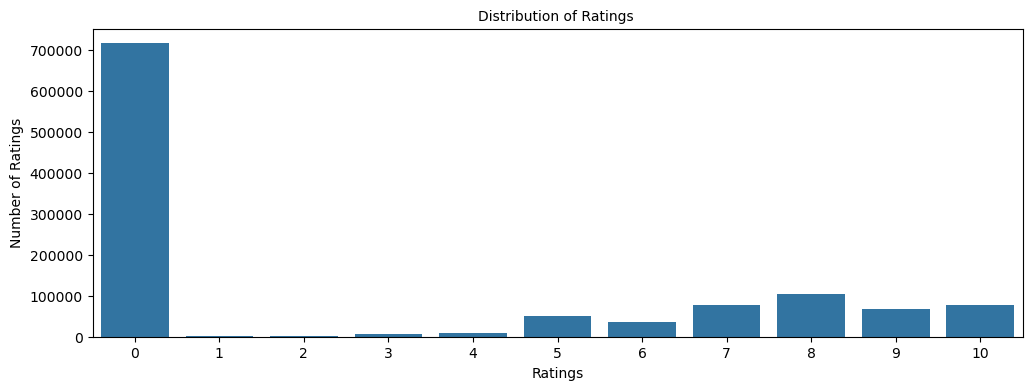

In [8]:
plt.figure(figsize = (12, 4))
sns.countplot(x='rating', data=df)

plt.tick_params(labelsize = 10)
plt.title("Distribution of Ratings ", fontsize = 10)
plt.xlabel("Ratings", fontsize = 10)
plt.ylabel("Number of Ratings", fontsize = 10)
plt.show()

**Observations:**

- The rating scale ranges from **0 to 10**, representing user feedback for books.
- A very large proportion of the entries (**716,109 ratings**) are **0**, which likely indicates **implicit feedback or missing ratings** rather than actual user evaluations.
- Excluding zero ratings, the majority of explicit ratings fall between **7 and 10**, suggesting that users tend to give **generally positive reviews**.
- Ratings **8 (103,736)**, **10 (78,610)**, and **7 (76,457)** are among the most frequent explicit ratings, indicating strong user preference for higher scores.
- Lower ratings (**1–4**) are relatively rare compared to higher ratings, suggesting either **user bias toward positive feedback** or that users are more likely to rate books they enjoy.
- The heavy imbalance between **zero ratings and explicit ratings** suggests that **data preprocessing may be required**, such as filtering out zero ratings when building collaborative filtering models.

#### **2. Row Dropping (rating = 0)**

In [9]:
df.drop(df.index[df['rating'] == 0], inplace = True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 433671 entries, 1 to 1149779
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   user_id              433671 non-null  int64 
 1   book_id              433671 non-null  object
 2   rating               433671 non-null  int64 
 3   Book-Title           383842 non-null  object
 4   Book-Author          383841 non-null  object
 5   Year-Of-Publication  383842 non-null  object
 6   Publisher            383840 non-null  object
dtypes: int64(2), object(5)
memory usage: 26.5+ MB


**Observations:**

- After filtering out ratings with a value of **0**, the dataset size reduced from **1,149,780 to 433,671 records**, leaving only **explicit user ratings**.
- The dataset now represents **active user feedback**, which is more suitable for building **collaborative filtering recommendation models**.
- The dataset still contains **7 columns**, including user identifiers, book identifiers, rating values, and book metadata.
- The **user_id** and **rating** columns remain numeric (`int64`), while book-related attributes are stored as `object` types.
- Some book metadata fields still contain **missing values**:
  - **Book-Title**: 383,842 non-null values  
  - **Book-Author**: 383,840 non-null values  
  - **Year-Of-Publication**: 383,842 non-null values  
  - **Publisher**: 383,840 non-null values
- The presence of missing metadata suggests that **additional data cleaning or filtering may be required**, especially if these attributes are used for analysis or hybrid recommendation approaches.
- Removing zero ratings significantly **reduces noise in the dataset**, allowing the recommendation models to focus on **meaningful user preferences**.

#### **3. Updated Rating Distribution**

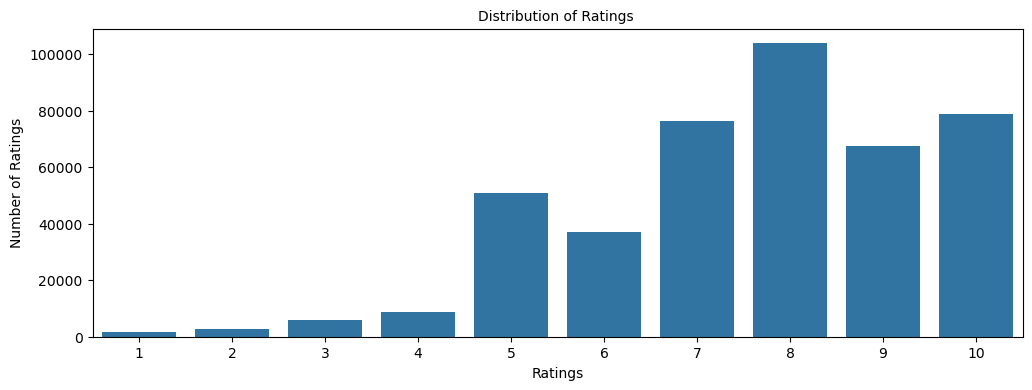

In [11]:
# Distribution of ratings
plt.figure(figsize = (12, 4))
sns.countplot(x='rating', data=df)

plt.tick_params(labelsize = 10)
plt.title("Distribution of Ratings ", fontsize = 10)
plt.xlabel("Ratings", fontsize = 10)
plt.ylabel("Number of Ratings", fontsize = 10)
plt.show()

**Observations:**

- After removing ratings with a value of **0**, the dataset contains **433,671 explicit ratings** ranging from **1 to 10**.
- The distribution shows a clear **positive bias**, with higher ratings occurring much more frequently than lower ratings.
- The most common ratings are **8 (103,736)**, **10 (78,610)**, and **7 (76,457)**, indicating that users tend to give favorable reviews to books they rate.
- Mid-range ratings such as **5 (50,974)** and **6 (36,924)** appear less frequently than higher ratings but still represent a substantial portion of the dataset.
- Very low ratings (**1–3**) are relatively rare, suggesting that users may be **less likely to rate books they strongly dislike**.
- The skew toward higher ratings is common in recommendation datasets and may introduce **rating bias**, which should be considered when interpreting model performance.

#### **4. Data Quality**

##### **4.1 Number of Unique Users**

In [12]:
df['user_id'].nunique()

77805

##### **4.2 Number of Unique Books**

In [13]:
df['book_id'].nunique()

185973

**Observations:**

- The dataset contains **77,805 unique users**, indicating a large and diverse user base interacting with the platform.
- There are **185,973 unique books**, suggesting a very broad catalog of items available for recommendation.
- The number of **books is significantly larger than the number of users**, which is common in recommendation datasets and indicates a **large item space**.
- Given **433,671 total ratings**, the user–item interaction matrix is expected to be **highly sparse**, meaning most users have rated only a small subset of all available books.
- Data sparsity is a typical challenge in collaborative filtering systems and may impact model performance, making techniques such as **matrix factorization** useful for uncovering latent user–item relationships.

##### **4.3 Dataset Aggregation and Validation**

In [14]:
df.groupby(['user_id', 'book_id']).count()

rating  Book-Title  Book-Author  Year-Of-Publication  \
user_id book_id                                                            
8       0002005018       1           1            1                    1   
        074322678X       1           1            1                    1   
        0887841740       1           1            1                    1   
        1552041778       1           1            1                    1   
        1567407781       1           1            1                    1   
...                    ...         ...          ...                  ...   
278854  0375703063       1           1            1                    1   
        042516098X       1           1            1                    1   
        0425163393       1           1            1                    1   
        0553275739       1           1            1                    1   
        0553579606       1           1            1                    1   

                    Publisher  
user_id book_id                
8       0002005018          1  
        074322678X          1  
        0887841740          1  
        1552041778          1  
        1567407781          1  
...                       ...  
278854  0375703063          1  
        042516098X          1  
        0425163393          1  
        0553275739          1  
        0553579606          1  

[433671 rows x 5 columns]

In [15]:
df.groupby(['user_id', 'book_id']).count()['rating'].sum()

433671

**Observation:**
- The **sum is equal to the total number of observations**, which implies that **there is only one interaction between a book and a user**.

#### **5. Data Insight: *Which book has the highest number of reviews / ratings in the dataset?***

##### **5.1 The Most Rated Books**

In [16]:
df['book_id'].value_counts()

0316666343    707
0971880107    581
0385504209    487
0312195516    383
0679781587    333
             ... 
0425184293      1
009928717X      1
000637610X      1
8433970038      1
0028618874      1
Name: book_id, Length: 185973, dtype: int64

**Observations:**

- The dataset contains **185,973 unique books**, but the number of ratings per book varies significantly.
- The most frequently rated books include:
  - **0316666343** with **707 ratings**
  - **0971880107** with **581 ratings**
  - **0385504209** with **487 ratings**
  - **0312195516** with **383 ratings**
  - **0679781587** with **333 ratings**
- A large number of books have **very few ratings**, with many books receiving **only one rating**.
- This distribution indicates a **long-tail pattern**, where a small number of popular books receive many ratings while the majority receive very few.
- The long-tail distribution contributes to **data sparsity**, which can make it difficult for similarity-based collaborative filtering models to generate reliable recommendations for less frequently rated books.
- Because of this sparsity, techniques such as **matrix factorization** are often useful, as they can learn **latent user–item relationships** even when explicit interactions are limited.

##### **5.2 User Distribution of the Most Popular (Rated) Book**

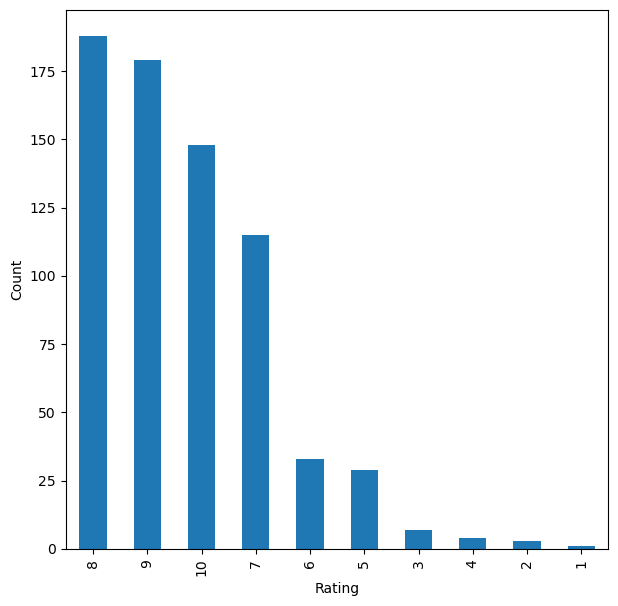

In [17]:
plt.figure(figsize=(7,7))

df[df['book_id'] == '0316666343']['rating'].value_counts().plot(kind='bar')

plt.xlabel('Rating')

plt.ylabel('Count')
plt.show()

**Observations:**

- The book **0316666343** received a total of **707 ratings**, making it the most frequently rated book in the dataset.
- The rating distribution is strongly **skewed toward higher ratings**, with the majority of ratings between **7 and 10**.
- The most common ratings are **8 (188 ratings)**, **9 (179 ratings)**, and **10 (148 ratings)**, indicating that readers generally rate this book very positively.
- Mid-range ratings such as **5 (29 ratings)** and **6 (33 ratings)** occur much less frequently.
- Very low ratings (**1–4**) are rare, suggesting that readers who rate this book typically have **favorable opinions** of it.
- This pattern illustrates a common phenomenon in recommendation datasets where **popular items tend to accumulate many high ratings**, reinforcing their visibility in rank-based recommendation systems.

##### **5.3 The Most Active User**

In [18]:
df['user_id'].value_counts()

11676     8524
98391     5802
153662    1969
189835    1906
23902     1395
          ... 
221206       1
208924       1
210973       1
204830       1
20086        1
Name: user_id, Length: 77805, dtype: int64

**Observations:**

- The dataset shows significant variation in **user activity levels**, measured by the number of ratings each user has submitted.
- The most active user (**user_id: 11676**) contributed **8,524 ratings**, making them a highly engaged participant in the dataset.
- Other highly active users include:
  - **user_id 98391** with **5,802 ratings**
  - **user_id 153662** with **1,969 ratings**
  - **user_id 189835** with **1,906 ratings**
  - **user_id 23902** with **1,395 ratings**
- In contrast, many users have contributed **only a single rating**, indicating a **long-tail distribution of user activity**.
- This imbalance suggests that while a small number of users provide a large portion of the interactions, the majority of users interact with only a few books.
- Such patterns are common in recommendation datasets and can introduce **user activity bias**, where highly active users influence collaborative filtering models more strongly than less active users.
- Understanding user activity distribution is important when designing recommendation systems, as it may motivate techniques such as **user filtering, regularization, or weighting strategies** to balance model learning.

### **iii. Data Preparation**

#### **1. Dataset Reduction**

Although the cleaned dataset contains **433,671 observations**, building recommendation models on the full dataset may still be **computationally expensive**. In addition, many users have rated only a few books, and many books have received very few ratings. Such sparse interactions can reduce the reliability of collaborative filtering models.

To address this issue, we apply filtering criteria to focus on more informative interactions:

- **User filtering**: retain only users who have provided **at least 50 ratings**, ensuring that each selected user has sufficient interaction history to model preferences.
- **Book filtering**: retain only books that have received **at least 10 ratings**, ensuring that each item has enough feedback for meaningful recommendations.

These thresholds help reduce data sparsity while preserving users and books with sufficient activity to support reliable recommendation modeling.

In [19]:
# Get the column containing the users
users = df.user_id
# Create a dictionary from users to find their number of books
ratings_count = dict()
for user in users:
    # If we already have the user, just add 1 to their rating count
    if user in ratings_count:
        ratings_count[user] += 1
    # Otherwise, set their rating count to 1
    else:
        ratings_count[user] = 1    

In [20]:
RATINGS_CUTOFF = 50
remove_users = []
for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)
df = df.loc[~df.user_id.isin(remove_users)]

In [21]:
df.shape

(175023, 7)

In [22]:
# Get the column containing the books
books = df.book_id
# Create a dictionary from books to find their number of users
ratings_count = dict()
for book in books:
    # If we already have the book, just add 1 to their rating count
    if book in ratings_count:
        ratings_count[book] += 1
    # Otherwise, set their rating count to 1
    else:
        ratings_count[book] = 1   

In [23]:
# We want our book to be interacted by at least 10 users to be considered
RATINGS_CUTOFF = 10
remove_books = []
for book, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_books.append(book)
df= df.loc[~df['book_id'].isin(remove_books)]

In [24]:
df.shape

(26698, 7)

**Observations:**

- Before applying the filtering criteria, the dataset contained **175,023 observations** with **7 columns**.
- After restricting the dataset to **users with at least 50 ratings** and **books with at least 10 ratings**, the dataset size reduced to **26,698 observations**.
- This reduction removes **low-activity users** and **rarely rated books**, which contribute little useful information for collaborative filtering models.
- Filtering helps mitigate the **data sparsity problem** by retaining users and books with sufficient interaction history.
- The resulting dataset is **smaller and more computationally efficient**, while still preserving meaningful user–item interactions for building recommendation models.

#### **2. User-Book Interaction Distribution in the New Dataset**

##### **2.1 Unique Count**

In [25]:
df.nunique()

user_id                1257
book_id                1497
rating                   10
Book-Title             1367
Book-Author             587
Year-Of-Publication      43
Publisher               204
dtype: int64

##### **2.2 User-Book Interactions Distribution**

In [26]:
count_interactions = df.groupby('user_id').count()['book_id']
count_interactions

user_id
254       18
638       20
643        3
1025       7
1211       3
          ..
277427    36
278026    11
278137     8
278188     9
278418     9
Name: book_id, Length: 1257, dtype: int64

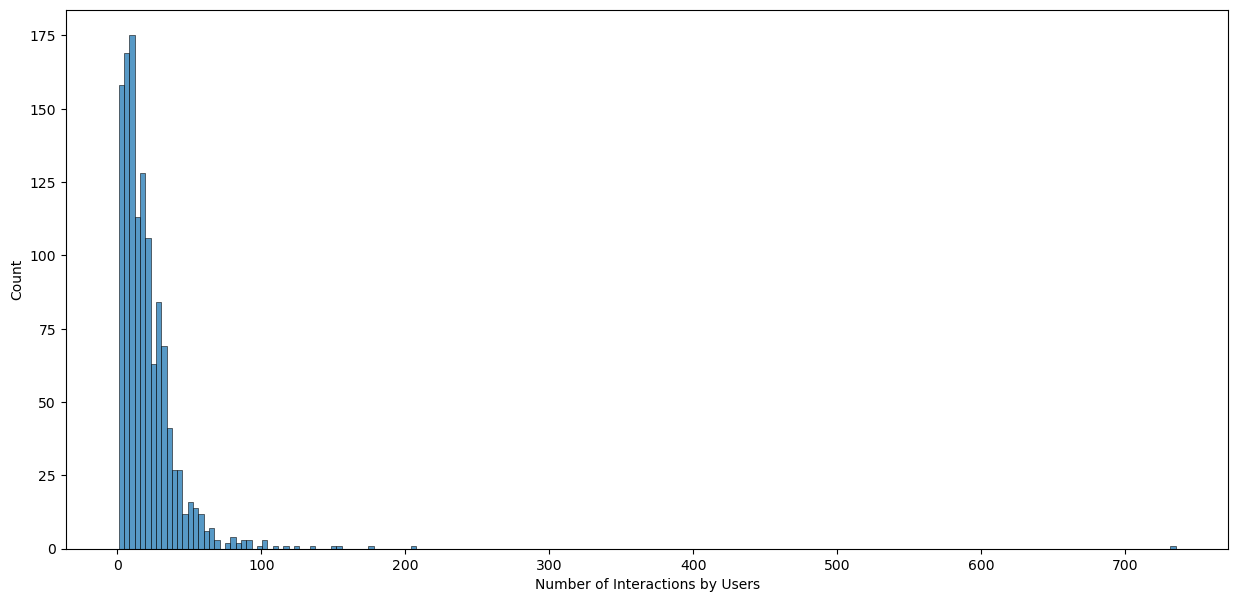

In [27]:
plt.figure(figsize=(15,7))
sns.histplot(count_interactions)
plt.xlabel('Number of Interactions by Users')
plt.show()

**Observations:**

- The distribution is highly skewed to the right.
- It clearly shows that there are very few books which have many ratings.

## **III. Models**

### **i. Model 1: Rank-Based Recommendation System**

- Rank-based recommendation systems suggest items based on their **overall popularity or average rating** across all users. This approach is particularly useful for addressing the **cold start problem**, which occurs when a **new user enters the system without any prior interaction history**. Since the system has no information about the user’s preferences, personalized recommendations cannot be generated. In such cases, recommending **top-ranked or most popular books** provides a reasonable starting point.

- To build the rank-based recommendation model, we compute the **average rating for each book** using all available user ratings. The books are then **ranked according to their average rating**, and the highest-ranked books are recommended to users as the most popular or well-received items in the dataset.

#### **1. DataFrame Preparation**

In [28]:
average_rating = df.groupby('book_id')['rating'].mean()
count_rating = df.groupby('book_id')['rating'].count()
final_rating = pd.DataFrame({'avg_rating': average_rating, 'rating_count': count_rating})

In [29]:
final_rating.head()

,avg_rating,rating_count
book_id,,
0020442203,8.727273,11
002542730X,7.428571,28
0028604199,8.000000,10
0060002050,7.800000,10
006000438X,7.666667,15


In [30]:
final_rating['rating_count'].value_counts()

10     237
11     196
12     161
13     114
14     104
      ... 
62       1
60       1
46       1
47       1
145      1
Name: rating_count, Length: 65, dtype: int64

#### **2. Function Preparation**

In [31]:
def top_n_books(data, n, min_interaction=100):
    
    recommendations = data[data['rating_count']>min_interaction]
    recommendations = recommendations.sort_values(by='avg_rating', ascending=False)

    return recommendations.index[:n]

#### **3. Recommendations**

**`Top 5` book, `10 minimum` interactions based on popularity**

In [32]:
res = list(top_n_books(final_rating, 5, 10))
list_of_books = []
for i in res:
    list_of_books.append(df[df['book_id']== str(i)]['Book-Title'].unique()[0])
list_of_books

['The Two Towers (The Lord of the Rings, Part 2)',
 'Harry Potter and the Chamber of Secrets Postcard Book',
 "My Sister's Keeper : A Novel (Picoult, Jodi)",
 'The Giving Tree',
 'A Tree Grows in Brooklyn']

**`Top 5` book, `100 minimum` interactions based on popularity**

In [33]:
res2 = list(top_n_books(final_rating, 5, 100))
# Name of the books
list_of_book = []
for i in res2:
    list_of_book.append(df[df['book_id']== str(i)]['Book-Title'].unique()[0])
list_of_book

['The Da Vinci Code', 'The Lovely Bones: A Novel']

### **ii. Model 2: Collaborative Filtering Based Recommendation System**

In collaborative recommendation systems, recommendations are generated using **user–item interaction data**, without requiring additional information about user demographics or item attributes. The system identifies patterns in how users interact with items and leverages these patterns to suggest relevant items to similar users.

Common types of user–item interactions include:

1. **Ratings** provided by users  
   - Examples: book ratings on Goodreads, movie ratings on IMDB.

2. **Likes or reactions** from users  
   - Examples: likes on Facebook posts or YouTube videos.

3. **Purchasing or usage behavior**  
   - Examples: buying products on e-commerce platforms such as Amazon.

4. **Content consumption activity**  
   - Examples: reading articles on blogs or viewing content on online platforms.

These interaction signals enable the system to **infer user preferences and discover similarities between users or items**, forming the basis for collaborative filtering recommendations.

The types of collaborative filtering include

- Similarity/Neighborhood based
- Model based

#### **1. Function Preparation**

The following function takes a **recommendation model** as input and computes the **Precision@K** and **Recall@K** metrics for evaluating the model’s performance. For each user, the **top K predicted items** are considered when calculating these evaluation metrics.

In [34]:
def precision_recall_at_k(model, k=10, threshold=7):

    user_est_true = defaultdict(list)
    predictions=model.test(testset)
    
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)),3)
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)),3)
    
    accuracy.rmse(predictions)
    print('Precision: ', precision)
    print('Recall: ', recall)
    print('F_1 score: ', round((2*precision*recall)/(precision+recall),3))

#### **2. Data Preparation**

##### **2.1 `user_id` `book_id` Encoding**

In [35]:
data=df[['user_id','book_id']].apply(LabelEncoder().fit_transform)
data['rating']=df['rating']
data.head()

,user_id,book_id,rating
1211,1251,521,9
1213,1251,524,9
1214,1251,525,8
1456,1252,1,10
1474,1252,52,9


In [36]:
df_rating = data.copy()

##### **2.2 Dataset**

In [37]:
average_rating = data.groupby('book_id')['rating'].mean()
count_rating = data.groupby('book_id')['rating'].count()

final_rating = pd.DataFrame({'avg_rating': average_rating, 'rating_count': count_rating})
final_rating.head()

,avg_rating,rating_count
book_id,,
0,8.727273,11
1,7.428571,28
2,8.000000,10
3,7.800000,10
4,7.666667,15


##### **2.3 Surprise Dataset**

In [38]:
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(data[['user_id', 'book_id', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.3, random_state=42)

#### **3.1 User-Based Collaborative Filtering Recommendation System**

In [39]:
sim_options = {'name': 'cosine',
               'user_based': True}
algo_knn_user = KNNBasic(sim_options=sim_options,verbose=False)
algo_knn_user.fit(trainset)
precision_recall_at_k(algo_knn_user)

RMSE: 1.8455
Precision:  0.816
Recall:  0.812
F_1 score:  0.814


**Observations:**

- The **Root Mean Squared Error (RMSE)** of **1.8455** indicates the average deviation between predicted ratings and actual user ratings. While the error is moderate, rating prediction accuracy is not the primary objective in top-N recommendation tasks.

- The model achieved a **Precision@K of 0.816**, meaning that approximately **81.6% of the recommended books in the top-K list are relevant** to the user.

- The **Recall@K of 0.812** shows that the model successfully retrieves about **81.2% of the relevant items** that users actually interacted with.

- The **F1-score of 0.814** reflects a **balanced trade-off between precision and recall**, indicating that the model maintains both good recommendation accuracy and good coverage of relevant items.

- Overall, the results suggest that the **user–user similarity-based collaborative filtering model performs well in identifying relevant book recommendations**, even though the RMSE indicates room for improvement in precise rating prediction.

#### **3.2 Recommendations**

##### **3.2.1 `Id = 1326` `book_id = 12126`**

In [40]:
algo_knn_user.predict(1326,12126, r_ui=8, verbose=True)

user: 1326       item: 12126      r_ui = 8.00   est = 7.99   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=1326, iid=12126, r_ui=8, est=7.9887628424657535, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Observations:**

- The prediction output shows a case where **either the user or the item was not present in the training dataset** used to build the recommendation model.
- The flag **`was_impossible: True`** indicates that the model could not compute a similarity-based prediction because it had **no prior interaction data for the user, the item, or both**.
- In such cases, the model returns a **default estimated rating (`est ≈ 7.99`)**, which is typically derived from the **global average rating of the dataset**.
- This situation is an example of the **cold start problem**, where the recommendation system lacks sufficient historical data to generate a personalized prediction.
- Handling such scenarios often requires alternative strategies such as **rank-based recommendations, popularity-based recommendations, or hybrid models that incorporate item metadata**.

##### **3.2.2`Id = 1326` `book_id = 2150`**

In [41]:
algo_knn_user.predict(1326,2150, verbose=True)

user: 1326       item: 2150       r_ui = None   est = 7.99   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=1326, iid=2150, r_ui=None, est=7.9887628424657535, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Observations:**

- The prediction indicates that the model attempted to estimate a rating for **user 1326** on **item 2150**, but the interaction could not be properly evaluated because **either the user or the item was not present in the training dataset**.
- The flag **`was_impossible: True`** confirms that the collaborative filtering model could not compute a similarity-based prediction due to the absence of historical interaction data.
- The value **`r_ui = None`** indicates that there is **no actual rating available** for this user–item pair, meaning the prediction is purely generated by the model.
- In this situation, the algorithm returns a **default estimated rating (`est ≈ 7.99`)**, which typically corresponds to the **global mean rating of the dataset**.
- This scenario represents a **cold start or unknown entity case**, where the model lacks sufficient information to produce a personalized recommendation.
- To handle such situations, recommendation systems often rely on **fallback strategies**, such as **rank-based recommendations or popularity-based recommendations**.

#### **4.1 Hyperparameters Tuning**

In [42]:
# Set up parameter grid to tune the hyperparameters
param_grid = {'k': [20, 30, 40], 'min_k': [3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine'],
                              'user_based': [True]}
              }
# Perform 3-fold cross validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid, measures=['rmse', 'mae'], cv=3, n_jobs=-1)
# Fit the data
gs.fit(data)
# Best RMSE score
print(gs.best_score['rmse'])
# Combination of parameters that gave the best RMSE score
print(gs.best_params['rmse'])

1.7017230218687234
{'k': 20, 'min_k': 6, 'sim_options': {'name': 'msd', 'user_based': True}}


**Final Model**

In [43]:
# Use the optimal similarity measure for user-based collaborative filtering
sim_options = {'name': 'msd', 'user_based': True}
# Create an instance of KNNBasic with optimal hyperparameter values
similarity_algo_optimized = KNNBasic(sim_options=sim_options, k=20, min_k=6, verbose=False)
# Train the algorithm on the train set
similarity_algo_optimized.fit(trainset)
# Compute precision@k and recall@k with k=10.
precision_recall_at_k(similarity_algo_optimized)

RMSE: 1.6866
Precision:  0.834
Recall:  0.891
F_1 score:  0.862


**Observations:**

- After applying **hyperparameter tuning**, the model shows an improvement in overall performance compared to the baseline model.

- The **RMSE decreased to 1.6866**, indicating that the model’s predicted ratings are **closer to the actual user ratings**, reflecting better rating prediction accuracy.

- The **Precision@K increased to 0.834**, meaning that approximately **83.4% of the recommended books in the top-K list are relevant** to users.

- The **Recall@K improved to 0.891**, suggesting that the model successfully retrieves **89.1% of the relevant items**, demonstrating strong coverage of user-preferred books.

- The **F1-score of 0.862** indicates a **well-balanced trade-off between precision and recall**, showing that the model provides both accurate and comprehensive recommendations.

- Overall, the tuned model performs **more effectively than the initial model**, demonstrating that **optimizing similarity parameters and neighborhood settings can significantly enhance collaborative filtering performance**.

#### **4.2 Recommendations**

##### **4.2.1 `user_id=1326` `book_id=12126`**

In [44]:
similarity_algo_optimized.predict(1326, 12126, r_ui=8, verbose=True)

user: 1326       item: 12126      r_ui = 8.00   est = 7.99   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=1326, iid=12126, r_ui=8, est=7.9887628424657535, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Observations:**

- The prediction shows the estimated rating for **user 1326** on **book 12126**, where the actual rating provided by the user is **8**.
- The model produced an estimated rating of **7.99**, which is **very close to the true rating**, suggesting that the model’s overall rating scale is well calibrated.
- However, the prediction details indicate **`was_impossible: True`**, meaning the model could not generate the prediction using similarity-based collaborative filtering.
- This occurs because **either the user, the item, or both were not present in the training dataset**, preventing the algorithm from computing neighbor-based similarities.
- In such cases, the model falls back to a **default estimate (approximately the global average rating of the dataset)** rather than a personalized prediction.
- This result highlights a limitation of collaborative filtering models when dealing with **unseen users or items**, commonly referred to as the **cold start problem**.

##### **4.2.2 `user_id=1326` `book_id=2150`**

In [45]:
similarity_algo_optimized.predict(1326, 2150, verbose=True)

user: 1326       item: 2150       r_ui = None   est = 7.99   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=1326, iid=2150, r_ui=None, est=7.9887628424657535, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Observations:**

- The model generated a predicted rating for **user 1326** on **book 2150**, even though the user has **not previously rated this item** (`r_ui = None`).
- The estimated rating is **7.99**, which is close to the **global average rating** of the dataset.
- The flag **`was_impossible: True`** indicates that the model could not compute a similarity-based prediction because **either the user or the item was not present in the training dataset**.
- Since the collaborative filtering algorithm relies on historical interactions, the absence of user–item information prevents the model from identifying **similar users or similar items**.
- As a fallback, the algorithm returns a **default estimate based on the global mean rating**, rather than a personalized prediction.
- This scenario demonstrates a common limitation of collaborative filtering models known as the **cold start problem**, where recommendations for **new users or new items** cannot be generated effectively without sufficient historical data.

##### **4.2.3 Nearest Neighbors**

In [46]:
similarity_algo_optimized.get_neighbors(1, k=5)

[7, 23, 95, 107, 109]

#### **5. Recommendation Algorithm Implementation Based on Optimized KNNBasic Model**

In [47]:
def get_recommendations(data, user_id, top_n, algo):
    
    recommendations = []
    user_item_interactions_matrix = data.pivot(index='user_id', columns='book_id', values='rating')
    non_interacted_items = user_item_interactions_matrix.loc[user_id][user_item_interactions_matrix.loc[user_id].isnull()].index.tolist()
    for book_id in non_interacted_items:
        est = algo.predict(user_id, book_id).est
        recommendations.append((book_id, est))

    recommendations.sort(key=lambda x: x[1], reverse=True)

    return recommendations[:top_n]

In [48]:
df_rating=df_rating.drop_duplicates()

**`Top 5` items for `userId=1`**

In [49]:
recommendations = get_recommendations(df_rating, 1, 5, similarity_algo_optimized)

In [50]:
pd.DataFrame(recommendations, columns=['book_Id', 'predicted_ratings'])

,book_Id,predicted_ratings
0,259,10.000000
1,1297,9.884446
2,658,9.870802
3,639,9.764398
4,451,9.702661


#### **6. Ratings and Ranking Correction**

When comparing the quality of two books, the **average rating alone does not fully capture user preference**. The **number of users who have rated the book** is also an important factor, as ratings based on a larger number of observations are generally more reliable.

To account for this, we compute **corrected ratings** that consider both the **average rating** and the **number of ratings (`rating_count`)** for each book. In general, a book with a higher number of ratings provides a **more stable and trustworthy estimate of user preference**.

For example, a book with an **average rating of 8 based on only 5 ratings** may be less reliable than a book with an **average rating of 7 based on 50 ratings**, because the larger sample size provides stronger evidence of consistent user satisfaction.

Empirical studies suggest that the **reliability of a rating increases with the number of ratings**, and adjustments can be applied so that the estimated popularity of a book reflects both **rating value and rating volume**. One such approach scales the rating by a factor related to the **inverse square root of the rating count**, helping balance highly rated but sparsely reviewed books against consistently rated popular books.

In [51]:
def ranking_books(recommendations, final_rating):

  ranked_books = final_rating.loc[[items[0] for items in recommendations]].sort_values('rating_count', ascending=False)[['rating_count']].reset_index()
  ranked_books = ranked_books.merge(pd.DataFrame(recommendations, columns=['book_id', 'predicted_ratings']), on='book_id', how='inner')
  ranked_books['corrected_ratings'] = ranked_books['predicted_ratings'] - 1 / np.sqrt(ranked_books['rating_count'])
  ranked_books = ranked_books.sort_values('corrected_ratings', ascending=False)
  
  return ranked_books

**Note:** In the **above-corrected rating formula**, we can add the **quantity `1/np.sqrt(n)` instead of subtracting it to get more optimistic predictions**. But here we are **subtracting this quantity**, as there are some books with ratings 10 and **we can't have a rating more than 10 for a book**.

In [52]:
ranking_books(recommendations, final_rating)

,book_id,rating_count,predicted_ratings,corrected_ratings
3,259,31,10.000000,9.820395
0,658,53,9.870802,9.733441
2,1297,35,9.884446,9.715415
1,639,43,9.764398,9.611899
4,451,18,9.702661,9.466959


### **iii. Model 3: Item-Based Collaborative Filtering Recommendation System**

#### **1.1 User-Based Collaborative Filtering Recommendation System**

In [53]:
# Defining similarity measure
sim_options = {'name': 'cosine',
               'user_based': False}
# Defining nearest neighbour algorithm
algo_knn_item = KNNBasic(sim_options=sim_options,verbose=False)
# Train the algorithm on the train set 
algo_knn_item.fit(trainset)
# Compute precision@k, recall@k, and f_1 score with k=10
precision_recall_at_k(algo_knn_item)

RMSE: 1.6210
Precision:  0.802
Recall:  0.8
F_1 score:  0.801


**Observations:**

- The **item–item collaborative filtering model** achieved an **RMSE of 1.6210**, indicating improved rating prediction accuracy compared to earlier models. This suggests that item-based similarity captures user preferences more effectively for this dataset.

- The model obtained a **Precision@K of 0.802**, meaning that approximately **80.2% of the recommended books in the top-K list are relevant** to the users.

- The **Recall@K of 0.800** indicates that the model successfully retrieves **80.0% of the relevant books** that users actually interacted with.

- The **F1-score of 0.801** shows a **balanced performance between precision and recall**, demonstrating that the model maintains consistent recommendation quality.

- Overall, the results indicate that **item-based collaborative filtering performs reliably in identifying similar books**, though its precision and recall are slightly lower than the tuned user-based model. However, item-based approaches often provide **more stable recommendations in practice**, as item similarities tend to change less frequently than user preferences.

#### **1.2 Prediction for `user_id=1326` and `book_id=12126`**

In [54]:
algo_knn_item.predict(1326, 12126, r_ui=8, verbose=True)

user: 1326       item: 12126      r_ui = 8.00   est = 7.99   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=1326, iid=12126, r_ui=8, est=7.9887628424657535, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

In [55]:
algo_knn_item.predict(1326, 2150, verbose=True)

user: 1326       item: 2150       r_ui = None   est = 7.99   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=1326, iid=2150, r_ui=None, est=7.9887628424657535, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

#### **2. Hyperparameter Tuning**

In [56]:
# Set up parameter grid to tune the hyperparameters
param_grid = {'k': [10, 20, 30], 'min_k': [3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine'],
                              'user_based': [False]}
              }

# Perform 3-fold cross validation to tune the hyperparameters
grid_obj = GridSearchCV(KNNBasic, param_grid, measures=['rmse', 'mae'], cv=3)

# Fit the data
grid_obj.fit(data)

# Best RMSE score
print(grid_obj.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print(grid_obj.best_params['rmse'])

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matr

#### **3.1 Final Model**

In [57]:
# Create an instance of KNNBasic with optimal hyperparameter values
similarity_algo_optimized_item = KNNBasic(sim_options={'name': 'cosine', 'user_based': False}, k=30, min_k=3,verbose=False)
# Train the algorithm on the train set
similarity_algo_optimized_item.fit(trainset)
# Compute precision@k and recall@k with k=10
precision_recall_at_k(similarity_algo_optimized_item)

RMSE: 1.5882
Precision:  0.818
Recall:  0.836
F_1 score:  0.827


**Observations:**

- After applying **hyperparameter tuning**, the item-based collaborative filtering model shows further improvement in overall performance.

- The **RMSE decreased to 1.5882**, indicating that the model’s predicted ratings are **closer to the actual user ratings**, reflecting better rating prediction accuracy.

- The **Precision@K increased to 0.818**, meaning that approximately **81.8% of the recommended books in the top-K list are relevant** to users.

- The **Recall@K improved to 0.836**, suggesting that the model is able to **retrieve a larger proportion of relevant books** from the dataset.

- The **F1-score of 0.827** indicates a **strong balance between precision and recall**, demonstrating consistent recommendation quality.

- Overall, hyperparameter optimization enhances the model’s ability to capture **item similarity patterns**, resulting in **more accurate and effective book recommendations**.

#### **3.2 Predictions**

**`user_id=1326` `book_id= 12126`**

In [58]:
similarity_algo_optimized_item.predict(1326, 12126, r_ui=8, verbose=True)

user: 1326       item: 12126      r_ui = 8.00   est = 7.99   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=1326, iid=12126, r_ui=8, est=7.9887628424657535, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**`user_id=1326` `book_id= 2150`**

In [59]:
similarity_algo_optimized_item.predict(1326, 2150, verbose=True)

user: 1326       item: 2150       r_ui = None   est = 7.99   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=1326, iid=2150, r_ui=None, est=7.9887628424657535, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Observations:**

- The prediction results show that the model attempted to estimate ratings for **user 1326** on **items 12126 and 2150**.

- In both cases, the prediction details indicate **`was_impossible: True`**, meaning the model could not generate a similarity-based prediction because **either the user, the item, or both were not present in the training dataset**.

- As a fallback, the model returned an estimated rating of **7.99**, which corresponds approximately to the **global average rating of the dataset**.

- For **item 12126**, the actual rating (`r_ui`) is **8**, and the estimated rating **7.99** is very close to the true value. However, this is coincidental since the prediction was not generated using learned similarities.

- For **item 2150**, the value **`r_ui = None`** indicates that the user has **not rated this item**, and the prediction represents a purely estimated value.

- These results highlight a limitation of collaborative filtering models when dealing with **unknown users or unseen items**, commonly referred to as the **cold start problem**, where the system lacks sufficient interaction data to produce personalized recommendations.

#### **4. Identifying Five Similar Items to a Given Item (Nearest Neighbors of `BookId=1`)**

In [60]:
similarity_algo_optimized_item.get_neighbors(1, k=5)

[11, 12, 17, 21, 22]

In [61]:
recommendations = get_recommendations(df_rating, 1, 5, similarity_algo_optimized_item)

In [62]:
pd.DataFrame(recommendations, columns=['book_Id', 'predicted_ratings'])

,book_Id,predicted_ratings
0,1,10
1,15,10
2,16,10
3,17,10
4,30,10


In [63]:
ranking_books(recommendations, final_rating)

,book_id,rating_count,predicted_ratings,corrected_ratings
0,1,28,10,9.811018
1,15,13,10,9.722650
2,16,13,10,9.722650
3,17,12,10,9.711325
4,30,10,10,9.683772


### **iv. Model 4: Matrix Factorization**

#### **1. Baseline Matrix Factorization Recommendation System**

In [64]:
# SVD matrix factorization
svd = SVD(random_state=1)
# Train the algorithm on the train set
svd.fit(trainset)
# Compute precision@k and recall@k with k=10
precision_recall_at_k(svd)

RMSE: 1.5106
Precision:  0.827
Recall:  0.86
F_1 score:  0.843


**Observations:**

- The **SVD-based collaborative filtering model** achieved an **RMSE of 1.5106**, which is lower than the previously tested models. This indicates that the matrix factorization approach provides **more accurate rating predictions**.

- The model obtained a **Precision@K of 0.827**, meaning that approximately **82.7% of the recommended books in the top-K list are relevant** to users.

- The **Recall@K of 0.860** shows that the model is able to **retrieve a large proportion of relevant books**, demonstrating strong coverage of user-preferred items.

- The **F1-score of 0.843** reflects a **good balance between precision and recall**, indicating consistent recommendation quality.

- Compared with similarity-based collaborative filtering models, **SVD captures latent relationships between users and books**, allowing the system to better handle sparse interaction data.

- Overall, the results suggest that the **matrix factorization approach provides the most effective recommendation performance among the evaluated models**, improving both prediction accuracy and recommendation quality.

**`user_id=1326` and `book_id= 12126`**

In [65]:
svd.predict(1326, 12126, r_ui=8, verbose=True)

user: 1326       item: 12126      r_ui = 8.00   est = 7.99   {'was_impossible': False}


Prediction(uid=1326, iid=12126, r_ui=8, est=7.9887628424657535, details={'was_impossible': False})

**`user_id=1326` and `book_id= 2150`**

In [66]:
svd.predict(1326, 2150, verbose=True)

user: 1326       item: 2150       r_ui = None   est = 7.99   {'was_impossible': False}


Prediction(uid=1326, iid=2150, r_ui=None, est=7.9887628424657535, details={'was_impossible': False})

#### **2. Matrix Factorization Based Recommendation System Hyperparameter Tuning**

In [67]:
# Set the parameter space to tune
param_grid = {'n_epochs': [10, 20, 30], 'lr_all': [0.001, 0.005, 0.01],
              'reg_all': [0.2, 0.4, 0.6]}
# Perform 3-fold gridsearch cross validation
gs_ = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Fit data
gs_.fit(data)

# Best RMSE score
print(gs_.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print(gs_.best_params['rmse'])

1.5031708577786427
{'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.2}


#### **3. Final Model**

In [68]:
# Build the optimized SVD modelh
svd_optimized = SVD(n_epochs=30, lr_all=0.005, reg_all=0.2, random_state=1)

# Train the algorithm on the train set
svd_optimized=svd_optimized.fit(trainset)

# Compute precision@k and recall@k with k=10
precision_recall_at_k(svd_optimized)

RMSE: 1.5024
Precision:  0.829
Recall:  0.856
F_1 score:  0.842


**Observations:**

- After **hyperparameter tuning**, the SVD-based recommendation model achieved an **RMSE of 1.5024**, representing the **lowest prediction error among the evaluated models**. This indicates that the tuned model produces ratings that are closest to the true user ratings.

- The model achieved a **Precision@K of 0.829**, meaning that approximately **82.9% of the recommended books in the top-K list are relevant** to users.

- The **Recall@K of 0.856** indicates that the model successfully retrieves **85.6% of the relevant items**, demonstrating strong ability to capture books that users are likely to prefer.

- The **F1-score of 0.842** reflects a **balanced trade-off between precision and recall**, confirming that the model maintains both recommendation accuracy and good coverage of relevant items.

- Overall, the tuned **SVD matrix factorization model** provides the **best overall performance**, effectively capturing **latent relationships between users and books** and producing more reliable recommendations compared to similarity-based collaborative filtering approaches.

**`user_id=1326` `book_id=12126`**

In [69]:
# Making prediction for user_id 1326 and book_id 12126
svd_optimized.predict(1326, 12126, r_ui=8, verbose=True)

user: 1326       item: 12126      r_ui = 8.00   est = 7.99   {'was_impossible': False}


Prediction(uid=1326, iid=12126, r_ui=8, est=7.9887628424657535, details={'was_impossible': False})

**`user_id=1326` `book_id=2150`**

In [70]:
# Making prediction for user_id 1326 and book_id 2150
svd_optimized.predict(1326, 2150, verbose=True)

user: 1326       item: 2150       r_ui = None   est = 7.99   {'was_impossible': False}


Prediction(uid=1326, iid=2150, r_ui=None, est=7.9887628424657535, details={'was_impossible': False})

#### **4. Final Recommendation**

In [71]:
# Getting top 5 recommendations for user_id 1 using "svd_optimized" algorithm.
svd_recommendations = get_recommendations(df_rating, 1, 5, svd_optimized)

In [72]:
# Ranking book based on above recommendations. Hint: use ranking_books function
ranking_books(svd_recommendations, final_rating)

,book_id,rating_count,predicted_ratings,corrected_ratings
0,70,32,10,9.823223
1,65,15,10,9.741801
2,73,14,10,9.732739
3,16,13,10,9.722650
4,34,12,10,9.711325


## **IV. Conclusions**

In this project, multiple recommendation approaches were developed and evaluated to build an effective **book recommendation system** using user–book interaction data. The study explored three major recommendation strategies: **rank-based recommendation**, **similarity-based collaborative filtering**, and **matrix factorization using SVD**.

The **rank-based recommendation system** served as a useful baseline and addressed the **cold start problem**, where new users have no prior interaction history. By recommending books with the highest average ratings, the system provides reasonable suggestions when personalized recommendations are not yet possible.

Next, **collaborative filtering models** were implemented using both **user–user similarity** and **item–item similarity** approaches. These models leverage patterns in user interactions to identify similarities between users or items. The results demonstrated that collaborative filtering can effectively capture user preferences, although performance may be affected by **data sparsity** and limited interaction histories.

Finally, a **matrix factorization model (SVD)** was applied to uncover **latent relationships between users and books**. This approach achieved the **best overall performance**, with the lowest RMSE and strong Precision@K, Recall@K, and F1-score metrics. By learning hidden factors that explain user preferences, the SVD model was able to generate more accurate and personalized recommendations compared to similarity-based methods.

Overall, the results indicate that **matrix factorization provides the most effective recommendation performance for this dataset**, particularly in handling sparse user–item interactions. However, simpler approaches such as **rank-based recommendations remain valuable for cold-start scenarios**, suggesting that a **hybrid recommendation strategy** could further improve system performance in real-world applications.